# Name:Ankit Vaghela
# USN:1AUA23BCS009
# LAB:10
# Sentiment Analysis using LSTM & Bidirectional LSTM
# Exercises
## Exercise 1: Load Dataset
### 1.	Load IMDB dataset from Keras.
### 2.	Display number of training and testing samples.
### 3.	Print first review (integer encoded).


In [12]:
# Import libraries

import numpy as np
from tensorflow.keras.datasets import imdb

# Load dataset (Top 10,000 words)

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Display number of samples

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# Print first review (integer encoded)

print("\nFirst Review (Encoded):")
print(X_train[0])

Training Samples: 25000
Testing Samples: 25000

First Review (Encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 1

## Exercise 2: Understanding Tokenization
### 1.	Explain why text must be converted into numbers.
### 2.	Display word index dictionary.
### 3.	Convert encoded review back to words (optional exploration).


In [13]:
from tensorflow.keras.datasets import imdb

# Get word index dictionary

word_index = imdb.get_word_index()

print("\nSample Word Index:")
print(dict(list(word_index.items())[:10]))


Sample Word Index:
{'fawn': 34701, 'tsukino': 52006, 'nunnery': 52007, 'sonja': 16816, 'vani': 63951, 'woods': 1408, 'spiders': 16115, 'hanging': 2345, 'woody': 2289, 'trawling': 52008}


## Exercise 3: Padding Sequences
### Reviews have different lengths.
### Tasks:
### 1.	Pad all sequences to length = 200.
### 2.	Explain why padding is required for RNN input.


In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad sequences

max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

print("Padded Shape:", X_train.shape)

Padded Shape: (25000, 200)


## Exercise 4: Data Visualization
### 1.	Print length of first 10 reviews.
### 2.	Plot distribution of review lengths.
### 3.	Comment on variability in text length.


Lengths of first 10 reviews:
[200, 200, 200, 200, 200, 200, 200, 200, 200, 200]


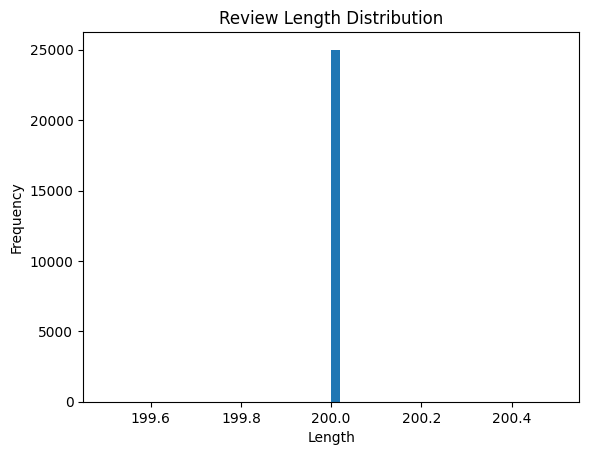

In [15]:
import matplotlib.pyplot as plt

# Length of first 10 reviews

lengths = [len(review) for review in X_train[:10]]

print("Lengths of first 10 reviews:")
print(lengths)

# Plot distribution

all_lengths = [len(review) for review in X_train]

plt.hist(all_lengths, bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## Exercise 5: LSTM Model Architecture
### Skeleton Code (Complete Missing Parts)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=200
    )
)

model_lstm.add(
    LSTM(64)
)

model_lstm.add(
    Dense(1, activation='sigmoid')
)

model_lstm.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

model_lstm.summary()

c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Exercise 6: Train LSTM Model
### Train model using:
### • Epochs = 5
### • Batch size = 64
### • Validation split = 0.2
### Plot training vs validation accuracy.


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.7904 - loss: 0.4439 - val_accuracy: 0.8498 - val_loss: 0.3560
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step - accuracy: 0.8965 - loss: 0.2694 - val_accuracy: 0.8718 - val_loss: 0.3231
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.9294 - loss: 0.1881 - val_accuracy: 0.8682 - val_loss: 0.3710
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step - accuracy: 0.9532 - loss: 0.1308 - val_accuracy: 0.8574 - val_loss: 0.3725
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 126ms/step - accuracy: 0.9635 - loss: 0.1047 - val_accuracy: 0.8638 - val_loss: 0.4348


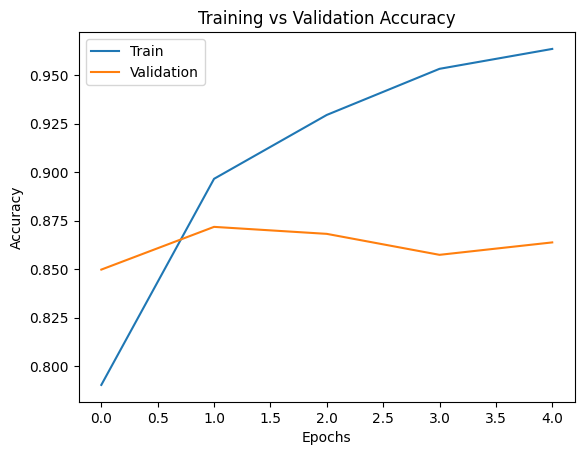

In [17]:
history_lstm = model_lstm.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=64,

    validation_split=0.2
)

# Plot Accuracy

plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

## Exercise 7: Model Evaluation
### 1.	Evaluate on test dataset.
### 2.	Report test accuracy.
### 3.	Compare training vs validation accuracy.


In [18]:
# Evaluate model

loss, accuracy = model_lstm.evaluate(

    X_test,
    y_test

)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8561 - loss: 0.4593
Test Accuracy: 0.8560799956321716


## Exercise 8: Confusion Matrix
### 1.	Predict sentiment for test set.
### 2.	Create confusion matrix.
### 3.	Interpret false positives and false negatives.


782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step
Confusion Matrix:
[[11016  1484]
 [ 2114 10386]]


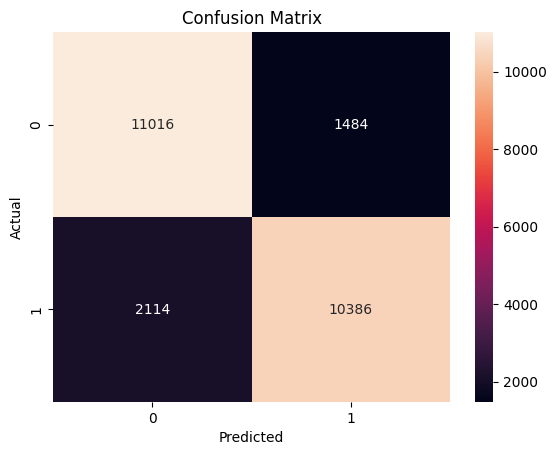

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict test data

y_pred = model_lstm.predict(X_test)

# Convert probabilities to labels

y_pred = (y_pred > 0.5)

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot

sns.heatmap(

    cm,

    annot=True,

    fmt='d'

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Exercise 9: Bidirectional LSTM
### Skeleton Code


In [20]:
from tensorflow.keras.layers import Bidirectional

model_bilstm = Sequential()

model_bilstm.add(
    Embedding(
        10000,
        128,
        input_length=200
    )
)

model_bilstm.add(
    Bidirectional(
        LSTM(64)
    )
)

model_bilstm.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_bilstm.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

# Train model

history_bilstm = model_bilstm.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=64,

    validation_split=0.2
)

Epoch 1/5


c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 158ms/step - accuracy: 0.7943 - loss: 0.4335 - val_accuracy: 0.8568 - val_loss: 0.3481
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 163ms/step - accuracy: 0.9039 - loss: 0.2467 - val_accuracy: 0.8668 - val_loss: 0.3127
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 206ms/step - accuracy: 0.9335 - loss: 0.1780 - val_accuracy: 0.8694 - val_loss: 0.3928
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 232ms/step - accuracy: 0.9539 - loss: 0.1285 - val_accuracy: 0.8568 - val_loss: 0.3968
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 252ms/step - accuracy: 0.9643 - loss: 0.0998 - val_accuracy: 0.8220 - val_loss: 0.4326


## Exercise 10: Model Comparison
### Create comparison table:


In [21]:
# Evaluate BiLSTM

loss_bi, acc_bi = model_bilstm.evaluate(
    X_test,
    y_test
)

import pandas as pd

comparison = pd.DataFrame({

    "Model": ["LSTM", "Bidirectional LSTM"],

    "Test Accuracy": [

        accuracy,
        acc_bi

    ],

    "Observations": [

        "Good performance",

        "Better context understanding"

    ]

})

print(comparison)

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8270 - loss: 0.4333
                Model  Test Accuracy                  Observations
0                LSTM        0.85608              Good performance
1  Bidirectional LSTM        0.82704  Better context understanding


## Exercise 11: Hyperparameter Experiment
### Modify and observe results:
### 1.	Increase embedding size (128 → 256)
### 2.	Increase sequence length (200 → 300)
### 3.	Add Dropout layer
### 4.	Increase epochs
### Record change in accuracy.


In [22]:
from tensorflow.keras.layers import Dropout

# New parameters

max_length = 300

# Re-pad sequences

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

# Modified Model

model_exp = Sequential()

model_exp.add(
    Embedding(
        input_dim=10000,
        output_dim=256
    )
)

model_exp.add(
    Bidirectional(
        LSTM(64)
    )
)

model_exp.add(
    Dropout(0.5)
)

model_exp.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_exp.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

# Train

history_exp = model_exp.fit(

    X_train,
    y_train,

    epochs=8,

    batch_size=64,

    validation_split=0.2
)

# Evaluate

loss_exp, acc_exp = model_exp.evaluate(

    X_test,
    y_test
)

print("Modified Model Accuracy:", acc_exp)

Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 495ms/step - accuracy: 0.7578 - loss: 0.4794 - val_accuracy: 0.8428 - val_loss: 0.3707
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 485ms/step - accuracy: 0.8974 - loss: 0.2626 - val_accuracy: 0.8684 - val_loss: 0.3161
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 116s 369ms/step - accuracy: 0.9305 - loss: 0.1857 - val_accuracy: 0.8622 - val_loss: 0.3350
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 292ms/step - accuracy: 0.9520 - loss: 0.1369 - val_accuracy: 0.8614 - val_loss: 0.3639
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 297ms/step - accuracy: 0.9669 - loss: 0.0976 - val_accuracy: 0.8642 - val_loss: 0.4245
Epoch 6/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 277ms/step - accuracy: 0.9743 - loss: 0.0794 - val_accuracy: 0.8364 - val_loss: 0.5043
Epoch 7/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.9762 - loss: 0.0694 - val_accuracy: 0.8506 - val_loss: 0.4988
Epoch 8/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 312ms/step - accuracy: 0.9870 - loss: 0.0426

## Exercise 12 — Analysis Answers

### Q1 — Why Embedding layer required?

### It converts words into dense vectors that capture meaning relationships.

### Q2 — Why padding necessary?

### Padding ensures all sequences have equal length for batch processing.

### Q3 — Why Bidirectional LSTM better?

### It reads text from both directions, capturing full context.

### Q4 — If sequence length too small?

### Important words may be removed, reducing accuracy.

### Q5 — Why sigmoid activation?

### Because output is binary classification (positive or negative).

##  Knowledge Check Answers (Any 5)

### 1.	What is tokenization?

### Process of converting text into numbers.

### 2.	Why are embeddings useful?

### Dense numeric representation of words.

### 3.RNN vs LSTM?

### LSTM solves vanishing gradient problem.

### What is Bidirectional RNN?

### Processes sequence in forward and backward direction.

### Why use Binary Cross-Entropy?

### Loss function used for binary classification.